In [1]:
import numpy as np
import sympy
from matplotlib import pyplot as plt
import pandas as pd
from scipy.stats import t
from formulaic import model_matrix
import seaborn as sns
sns.set_theme()

def show_matrix(m: pd.DataFrame, cmap="coolwarm", cbar=False, annot=True, **kwargs):
    axim = sns.heatmap(m.rename(columns=dict(Intercept="I")), cmap=cmap, cbar=cbar, annot=annot, **kwargs)
    axim.xaxis.set_ticks_position("top")
    axim.yaxis.set_ticks_position("right")

# Experiment matrix

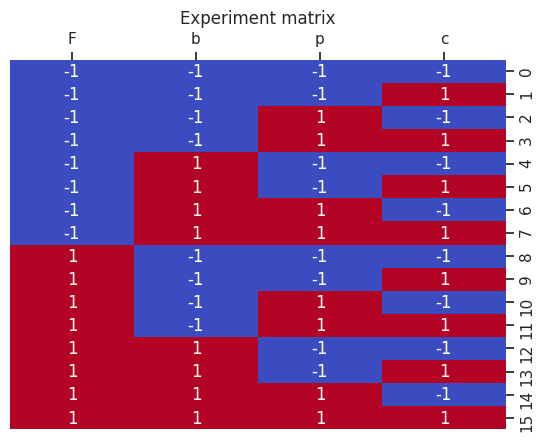

In [2]:
%matplotlib inline
E = pd.read_csv("matrix_experiment_standard.csv").rename(columns=dict(Fr="F"))
# E = 0.5*(1+E)*(np.exp(1)-np.exp(-1)) + np.exp(-1)
show_matrix(E)
plt.title("Experiment matrix")
plt.show()

# Model matrix

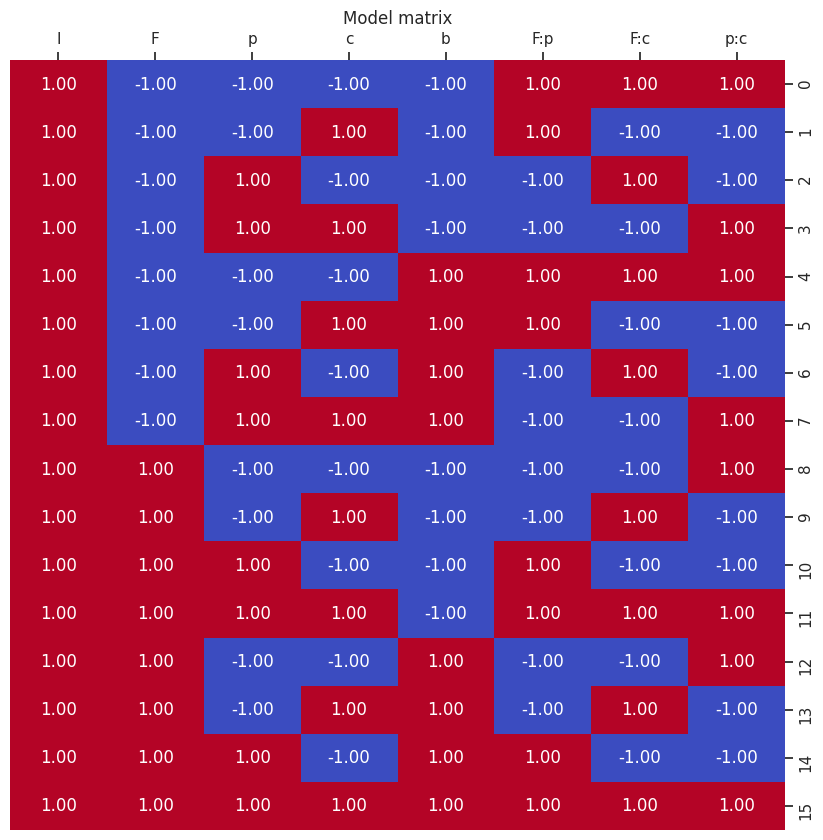

In [3]:
%matplotlib inline
M = model_matrix(
    "F + p + c + b + F:p + F:c + p:c",
    E
).rename(columns=dict(Intercept="I"))
M.to_csv("matrix_model.csv", index=False)

plt.figure(figsize=(10, 10))
show_matrix(M, fmt=".2f")
plt.title("Model matrix")
plt.show()

# Results

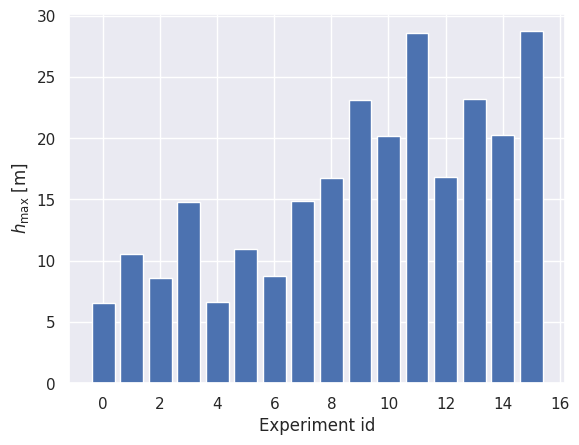

In [4]:
%matplotlib inline
R = np.loadtxt("hmax.csv", delimiter=",")
plt.bar(x=np.arange(R.size), height=R)
plt.xlabel("Experiment id")
plt.ylabel(r"$h_\mathrm{max}$ [m]")
plt.show()

# Effects

In [5]:
def half_effects(M, R):
    Half_effects = np.linalg.solve(M.T @ M, M.T @ R)
    Rel_effects = Half_effects / Half_effects[0]

    beta = 0.95
    alpha = 1-beta
    dof = M.shape[0] - M.shape[1]
    t_student = t.ppf(beta + alpha/2, dof)

    residue = R - M @ Half_effects
    var_exp = residue.T @ residue /(dof)
    D3 = np.linalg.inv(M.T @ M)
    CI = t_student * np.sqrt(np.diag(D3) * var_exp)

    return pd.DataFrame(
        np.vstack((Half_effects.T, CI.T, Rel_effects.T)),
        index=["Half-effects", f"{beta:.0%} CI", "Relative"],
        columns=[f"x_{c.replace(':', '')}" for c in M.columns]
    )

In [6]:
%matplotlib inline
effect_df = half_effects(M, np.log(R))

effects = effect_df.iloc[0]
effects.index = effects.index.str.replace(":", "")

display(
  effect_df
  .T
  .round(3)
  .style.background_gradient(cmap="coolwarm", axis="columns")
  .format(precision=3)
)

,Half-effects,95% CI,Relative
x_I,2.680,0.005,1.000
x_F,0.401,0.005,0.150
x_p,0.124,0.005,0.046
x_c,0.211,0.005,0.079
x_b,0.005,0.005,0.002
x_Fp,-0.024,0.005,-0.009
x_Fc,-0.044,0.005,-0.016
x_pc,0.010,0.005,0.004


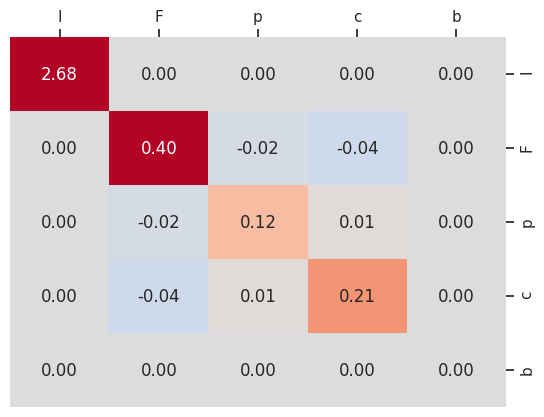

In [7]:
%matplotlib inline

M_main = M[M.columns[~M.columns.str.contains(":")]]

n_main = len(M_main.columns) - 1
effect_matrix = np.zeros((n_main, n_main), dtype=np.float16)

for i, f1 in enumerate(M_main.columns[1:]):
    for j, f2 in enumerate(M_main.columns[i+1:], start=i):
        if f1 == f2:
            f = f"x_{f1}"
        else:
            f = f"x_{f1}{f2}"
        if f in effects:
            effect_matrix[i, j] = effects[f]
            effect_matrix[j, i] = effects[f]

effect_matrix = np.pad(effect_matrix, ((1, 0), (1, 0)), mode="constant", constant_values=0)
effect_matrix[0, 0] = effects["x_I"]

effect_matrix = pd.DataFrame(effect_matrix, columns=M_main.columns)
vmax = np.abs(effect_matrix.drop(columns="I")).max(axis=None)

show_matrix(effect_matrix, vmin=-vmax, vmax=vmax, yticklabels=M_main.columns, fmt=".2f")
plt.show()

# ANOVA table

In [8]:
from statsmodels.api import stats #For ordinary least square "sm.OLS" 
from statsmodels.formula.api import ols #For ordinary least square "ols" not the same as above 
model = ols("1 ~ F + p + c + b", E)
result = model.fit()
anova_table = stats.anova_lm(result, typ=2)
display(anova_table)

,sum_sq,df,F,PR(>F)
F,7.703720e-32,1.0,0.238715,0.634730
p,0.000000e+00,1.0,0.000000,1.000000
c,4.930381e-32,1.0,0.152778,0.703359
b,9.321501e-32,1.0,0.288845,0.601664
Residual,3.549874e-30,11.0,NaN,NaN


# Predictions

In [9]:
variables = [np.prod([sympy.Symbol(f) for f in k[2:]], initial=1) for k in effects.index]
factors = [sympy.Symbol(k)*v for k, v in zip(effects.index, variables)]

predictor_analytical = sum(factors)
predictor = predictor_analytical.subs(effects.to_dict()).subs(dict(I=1))
predictor_main = predictor_analytical.subs({k: v if len(k)==3 else 0 for k, v in effects.items()}).subs(dict(I=1))

print("### Full expression ###")
print(predictor_analytical)
display(predictor_analytical)
print("### Substituting factors ###")
display(predictor)
print("### Ignoring interactions ###")
display(predictor_main)

### Full expression ###
F*c*x_Fc + F*p*x_Fp + F*x_F + I*x_I + b*x_b + c*p*x_pc + c*x_c + p*x_p


F*c*x_Fc + F*p*x_Fp + F*x_F + I*x_I + b*x_b + c*p*x_pc + c*x_c + p*x_p

### Substituting factors ###


-0.0436812542017642*F*c - 0.0242683193013432*F*p + 0.401129332482588*F + 0.00474511037423381*b + 0.00990661819454541*c*p + 0.211276691236913*c + 0.124155854051594*p + 2.67974505446016

### Ignoring interactions ###


0.401129332482588*F + 0.00474511037423381*b + 0.211276691236913*c + 0.124155854051594*p + 2.67974505446016

## Plotting surfaces and data

In [10]:
n = 100
x, y = np.meshgrid(np.linspace(-1, 1, num=n), np.linspace(-1, 1, num=n))
x, y = np.meshgrid(np.linspace(np.exp(-1), np.exp(1), num=n), np.linspace(np.exp(-1), np.exp(1), num=n))

def regression(debug=False, predictor=predictor, **kwargs):
    variables = [sympy.Symbol(c) for c in E.columns if c not in kwargs]
    p = predictor.subs(kwargs)
    if debug:
        print(variables)
        print(kwargs)
        display(predictor)
        display(p)
    return sympy.lambdify(variables, p)

def regression_main_factors(**kwargs):
    return regression(predictor=predictor_main, **kwargs)

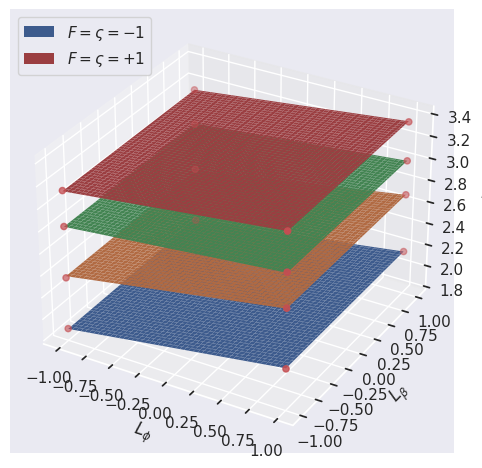

In [11]:
%matplotlib inline
#%matplotlib qt

x, y = np.meshgrid(np.linspace(E.p.min(), E.p.max(), num=n), np.linspace(E.b.min(), E.b.max(), num=n))

fig, axes = plt.subplots(subplot_kw=dict(projection="3d"), layout="tight")

axes.plot_surface(x, y, regression(F=E.F.min(), c=E.c.min())(p=x, b=y), lw=0, label=r"$F=\varsigma=-1$")
axes.plot_surface(x, y, regression(F=E.F.min(), c=E.c.max())(p=x, b=y), lw=0)
axes.plot_surface(x, y, regression(F=E.F.max(), c=E.c.min())(p=x, b=y), lw=0)
axes.plot_surface(x, y, regression(F=E.F.max(), c=E.c.max())(p=x, b=y), lw=0, label=r"$F=\varsigma=+1$")

axes.scatter(E["p"], E["b"], np.log(R), c="r")
axes.set_xlabel(r"$L_\phi$")
axes.set_ylabel(r"$L_\beta$")
axes.set_zlabel("$h$")
axes.legend(loc="upper left")
plt.show()

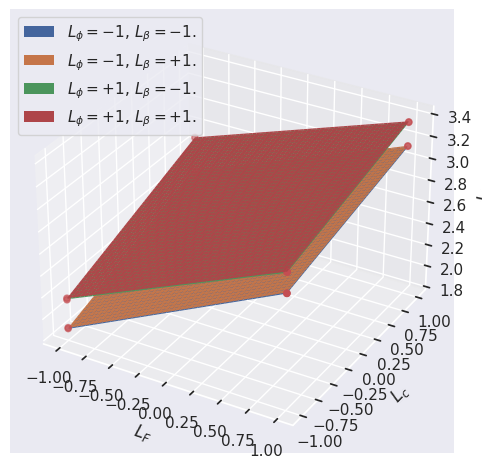

In [12]:
%matplotlib inline
#%matplotlib qt

x, y = np.meshgrid(np.linspace(E.F.min(), E.F.max(), num=n), np.linspace(E.c.min(), E.c.max(), num=n))

fig, axes = plt.subplots(subplot_kw=dict(projection="3d"), layout="tight")

axes.plot_surface(x, y, regression(p=E.p.min(), b=E.b.min())(F=x, c=y), lw=0, label=r"$L_\phi=-1,\,L_\beta=-1.$")
axes.plot_surface(x, y, regression(p=E.p.min(), b=E.b.max())(F=x, c=y), lw=0, label=r"$L_\phi=-1,\,L_\beta=+1.$")
axes.plot_surface(x, y, regression(p=E.p.max(), b=E.b.min())(F=x, c=y), lw=0, label=r"$L_\phi=+1,\,L_\beta=-1.$")
axes.plot_surface(x, y, regression(p=E.p.max(), b=E.b.max())(F=x, c=y), lw=0, label=r"$L_\phi=+1,\,L_\beta=+1.$")

axes.scatter(E["F"], E["c"], np.log(R), c="r")
axes.set_xlabel(r"$L_F$")
axes.set_ylabel(r"$L_c$")
axes.set_zlabel("$L_h$")
axes.legend(loc="upper left")
plt.show()

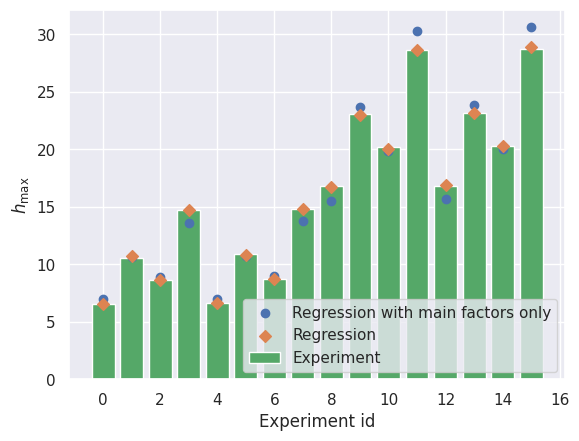

In [13]:
P = np.exp(regression()(**E))
Pm = np.exp(regression_main_factors()(**E))

xa = np.arange(E.shape[0])
plt.scatter(xa, Pm, label="Regression with main factors only", zorder=2)
plt.scatter(xa, P, marker="D", label="Regression", zorder=3)
plt.bar(xa, R, label="Experiment", zorder=1)
plt.legend(loc="lower right")
plt.xlabel("Experiment id")
plt.ylabel(r"$h_\mathrm{max}$")
plt.show()

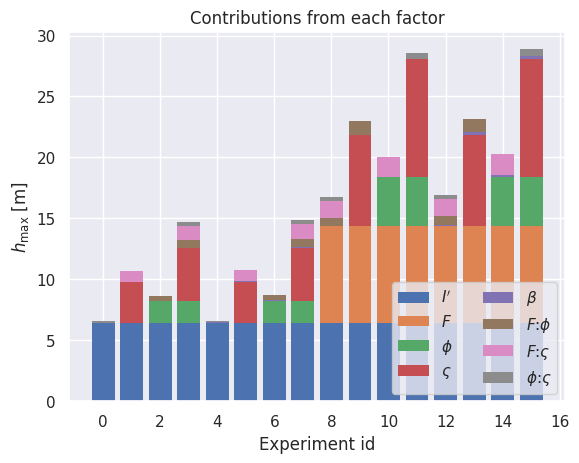

In [14]:
contributions = effects.values*M.values
base_effect = contributions.min(axis=0)
contributions -= base_effect
base_effect = base_effect.sum()
contributions = pd.DataFrame(contributions, columns=M.columns)
labels = dict(I="$I$", F="$F$", p=r"$\phi$", c=r"$\varsigma$", b=r"$\beta$")

plt.bar(xa, np.exp(base_effect), label="$I'$", lw=0, zorder=2)
for i, c in enumerate(M.columns[1:], start=1):
    label = "".join([labels.get(l, ":") for l in c])
    plt.bar(
        xa,
        np.exp(base_effect+contributions.values[:, :i+1].sum(axis=1)),
        label=label,
        lw=0,
        zorder=2-i/len(M.columns)
    )

plt.title("Contributions from each factor")
# plt.scatter(xa, R, zorder=1)
plt.xlabel("Experiment id")
plt.ylabel(r"$h_\mathrm{max}$ [m]")
plt.legend(loc="lower right", ncols=2)
plt.ylim(0, None)
plt.show()